# 04 - Correlacao

Esta etapa mede as correlacoes em `dataset_limpo_sem_corridas_encurtadas.csv`, saida do `03_Analise_Outliers.ipynb`. O arquivo e apenas lido: nenhuma linha ou coluna e alterada e nenhum dataset novo e salvo.

Cada linha e um piloto em uma corrida. A variavel de referencia e `rd_position_display_order`, a ordem oficial completa do resultado, que tambem e o alvo principal de `05_Leakage_Features.ipynb`. Ela vai de 1 (vencedor) ao ultimo colocado e coloca no fim da ordem os pilotos nao classificados (DNF, DNS, DSQ). Como 1 e o melhor resultado, **um coeficiente positivo significa que valores maiores da variavel acompanham resultados piores**; um coeficiente negativo, resultados melhores.

Cada afirmacao do texto se apoia em uma saida calculada logo acima dela. As premissas estruturais tambem sao conferidas com `assert`: se os dados mudarem e uma premissa deixar de valer, o notebook para em vez de manter um texto desatualizado.

In [1]:
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from feature_engineering import leakage_risk

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 160)

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c3c2b7', 'axes.grid': True, 'grid.color': '#e1e0d9',
    'axes.axisbelow': True, 'xtick.color': '#52514e', 'ytick.color': '#52514e',
})
AZUL, LARANJA, CINZA = '#2a78d6', '#eb6834', '#898781'
MAPA_DIVERGENTE = LinearSegmentedColormap.from_list(
    'azul_cinza_vermelho', ['#1c5cab', '#f0efec', '#e34948']
)

CAMINHO_DADOS = Path('dataset_limpo_sem_corridas_encurtadas.csv')
ALVO = 'rd_position_display_order'

df = pd.read_csv(CAMINHO_DADOS, low_memory=False)
print(f'Arquivo: {CAMINHO_DADOS}')
print(f'Dimensoes: {df.shape[0]:,} linhas x {df.shape[1]:,} colunas')
print(f'Corridas: {df["race_id"].nunique():,} | temporadas: {df["race_year"].min()}-{df["race_year"].max()}')

Arquivo: dataset_limpo_sem_corridas_encurtadas.csv
Dimensoes: 8,462 linhas x 137 colunas
Corridas: 403 | temporadas: 2003-2026


## 1. Estrutura do alvo dentro de cada corrida

O coeficiente de correlacao trata as linhas como observacoes. Antes de calcula-lo, conferimos como o alvo se distribui dentro de cada corrida: se ha uma linha por piloto e se a ordem vai de 1 ate o numero de participantes (N) sem repeticoes.

In [2]:
por_corrida = df.groupby('race_id')[ALVO].agg(['size', 'min', 'max', 'nunique'])
tamanho_grid = df.groupby('race_id')[ALVO].transform('size').rename('tamanho_grid')

linhas_repetidas = int(df.duplicated(['race_id', 'driver_id']).sum())
permutacao_completa = (
    por_corrida['min'].eq(1)
    & por_corrida['max'].eq(por_corrida['size'])
    & por_corrida['nunique'].eq(por_corrida['size'])
)
print(f'Linhas repetidas de piloto na mesma corrida: {linhas_repetidas}')
print(f'Corridas em que o alvo e uma permutacao de 1..N: {int(permutacao_completa.sum())} de {len(por_corrida)}')
print(f'N (pilotos por corrida): min {por_corrida["size"].min()} | mediana {por_corrida["size"].median():.0f} | max {por_corrida["size"].max()}')
assert linhas_repetidas == 0 and permutacao_completa.all()

ano_da_corrida = df.groupby('race_id')['race_year'].first()
print('\nN por temporada:')
display(por_corrida['size'].groupby(ano_da_corrida).agg(['min', 'max', 'mean']).round(1).T)

Linhas repetidas de piloto na mesma corrida: 0
Corridas em que o alvo e uma permutacao de 1..N: 403 de 403
N (pilotos por corrida): min 18 | mediana 20 | max 24

N por temporada:


race_year,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
min,20.0,20.0,18.0,22.0,22.0,20.0,20.0,24.0,22.0,24.0,22.0,18.0,20.0,22.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,19.0,20.0,22.0
max,20.0,20.0,20.0,22.0,22.0,22.0,20.0,24.0,24.0,24.0,22.0,22.0,20.0,22.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,22.0
mean,20.0,20.0,19.8,22.0,22.0,20.4,20.0,24.0,23.9,24.0,22.0,21.3,20.0,22.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,19.9,20.0,22.0


Em todas as corridas o alvo e exatamente uma permutacao de 1 ate N, e N varia entre 18 e 24 conforme a temporada. Isso tem duas consequencias usadas no resto do notebook:

- **As linhas de uma mesma corrida nao sao independentes.** Se um piloto ocupa a posicao 1, nenhum outro pode ocupa-la. O teste classico de significancia supoe independencia; por isso a secao 5 usa permutacoes do alvo dentro de cada corrida, que preservam essa restricao.
- **A media do alvo em cada corrida e sempre (N+1)/2**, porque a media de 1..N e (N+1)/2. Uma variavel constante dentro da corrida (ano, circuito, distancia) so pode se relacionar com o alvo por meio de N, nunca pela ordem entre os pilotos. A secao 6 verifica isso numericamente.

## 2. Variaveis analisadas

A correlacao de Spearman e a de Pearson exigem variaveis numericas. Das colunas numericas, `race_id` fica fora: e um codigo de identificacao, nao uma quantidade. As colunas de texto sao de dois tipos:

- cinco repetem posicoes que ja existem em uma coluna numerica, com codigos de situacao no lugar dos numeros ausentes. A tabela abaixo confere essa equivalencia.
- as demais sao categorias (piloto, equipe, circuito...). Elas nao tem ordem, entao entram na secao 11 com outra medida de associacao.

In [3]:
colunas_numericas = df.select_dtypes('number').columns.drop('race_id').tolist()
variaveis = [coluna for coluna in colunas_numericas if coluna != ALVO]

pares_texto = [
    ('rd_position_text', 'rd_position_number'),
    ('rd_race_grid_position_text', 'rd_race_grid_position_number'),
    ('sess_grid_position_text', 'sess_grid_position_number'),
    ('sess_quali_position_text', 'sess_quali_position_number'),
    ('cstand_position_text', 'cstand_position_number'),
]
linhas = []
for coluna_texto, coluna_numero in pares_texto:
    convertido = pd.to_numeric(df[coluna_texto], errors='coerce')
    numerico = convertido.notna()
    codigos = df.loc[df[coluna_texto].notna() & ~numerico, coluna_texto].value_counts()
    linhas.append({
        'coluna_texto': coluna_texto,
        'coluna_numerica': coluna_numero,
        'valores_numericos': int(numerico.sum()),
        'iguais_a_numerica': int(convertido[numerico].eq(df.loc[numerico, coluna_numero]).sum()),
        'codigos_nao_numericos': ', '.join(f'{codigo} ({qtd})' for codigo, qtd in codigos.items()),
    })
relatorio_texto = pd.DataFrame(linhas)
display(relatorio_texto)
assert relatorio_texto['valores_numericos'].eq(relatorio_texto['iguais_a_numerica']).all()

colunas_categoricas = (
    df.select_dtypes(exclude='number').columns
    .drop([coluna_texto for coluna_texto, _ in pares_texto])
    .tolist()
)
print(f'Colunas numericas analisadas: {len(colunas_numericas)} (alvo + {len(variaveis)} variaveis)')
print(f'Colunas de texto que espelham posicoes numericas: {len(pares_texto)}')
print(f'Colunas categoricas (secao 11): {len(colunas_categoricas)}')

,coluna_texto,coluna_numerica,valores_numericos,iguais_a_numerica,codigos_nao_numericos
0,rd_position_text,rd_position_number,6898,6898,"DNF (1462), DNS (56), DSQ (28), NC (14), DNQ (..."
1,rd_race_grid_position_text,rd_race_grid_position_number,8282,8282,PL (162)
2,sess_grid_position_text,sess_grid_position_number,8331,8331,PL (118)
3,sess_quali_position_text,sess_quali_position_number,8334,8334,"NC (82), EX (16), DSQ (8)"
4,cstand_position_text,cstand_position_number,8386,8386,EX (30)


Colunas numericas analisadas: 104 (alvo + 103 variaveis)
Colunas de texto que espelham posicoes numericas: 5
Colunas categoricas (secao 11): 27


Em todos os valores numericos, as cinco colunas de texto sao iguais a coluna numerica correspondente. O que sobra sao codigos de situacao, como DNF e DSQ, que nao sao quantidades. Portanto, essas colunas nao acrescentam nenhum valor numerico e ficam fora da correlacao.

### Momento em que cada variavel e conhecida

Uma correlacao alta com o resultado so ajuda a prever a corrida se a variavel for conhecida antes da largada. Para classificar as variaveis, usamos a funcao `leakage_risk` de `feature_engineering.py`, a mesma regra usada em `05_Leakage_Features.ipynb`. Variaveis sem restricao aparecem como `pre-largada`. A secao 7 confere com os dados duas dessas regras: resumos de carreira e standings.

In [4]:
momento = pd.Series(
    {coluna: leakage_risk(coluna) or 'pre-largada' for coluna in variaveis}, name='momento'
)
display(momento.value_counts().rename('variaveis').to_frame())

,variaveis
momento,
Resumo atual de carreira/fabricante; pode incluir o futuro,51
pre-largada,28
Campo de resultado/sessão sem liberação explícita como pré-largada,9
Standing atualizado após a corrida,8
Marcador de campeonato dependente do estado da temporada,2
Contagem atual de eventos; pode incluir corridas futuras,2
Agregação por temporada sem vigência por etapa comprovada,2
Volta mais rápida durante a corrida,1


## 3. Escolha do coeficiente e tratamento de nulos

**Spearman e o coeficiente principal.** O alvo e ordinal: registra a ordem de chegada, nao uma distancia medida entre os pilotos. Spearman usa apenas a ordem (os postos) das duas variaveis e mede associacoes monotonicas. Pearson mede associacao linear e e sensivel a caudas longas. A tabela abaixo mostra quantas variaveis tem distribuicao assimetrica. Pearson e reportado ao lado para indicar onde os dois coeficientes divergem.

In [5]:
assimetria = df[variaveis].skew().rename('assimetria')
print(f'Variaveis com |assimetria| > 1: {int(assimetria.abs().gt(1).sum())} de {len(variaveis)}')
print('Maiores assimetrias:')
display(assimetria.loc[assimetria.abs().sort_values(ascending=False).index].head(10).round(2).to_frame())

Variaveis com |assimetria| > 1: 36 de 103
Maiores assimetrias:


,assimetria
rd_race_grand_slam,20.00
dstand_championship_won,12.39
engmfr_best_starting_grid_position,12.38
ed_test_driver,9.18
cstand_championship_won,7.56
rd_race_pole_position,4.25
rd_race_fastest_lap,4.25
rd_race_driver_of_the_day,4.17
race_drivers_championship_decider,4.04
race_constructors_championship_decider,3.93


36 das 103 variaveis tem |assimetria| > 1, um limite usual para assimetria forte. Nesses casos, poucos valores extremos pesam muito no Pearson. Os postos do Spearman reduzem esse peso, o que confirma a escolha. A secao 4 mostra o efeito na pratica: as maiores diferencas entre os dois coeficientes aparecem justamente em variaveis assimetricas.

**Nulos.** O pandas usa exclusao por pares: cada coeficiente usa as linhas em que as duas colunas estao preenchidas. Assim, o numero de observacoes (`n`) muda de um par para outro e sempre aparece nas tabelas. As colunas com menor cobertura sao:

In [6]:
cobertura = df[variaveis].notna().sum().rename('n').sort_values()
display(cobertura.head(6).to_frame())

pontos_preenchidos = df['rd_race_points'].notna()
print('Ordem final nas linhas com e sem rd_race_points:')
display(df.groupby(pontos_preenchidos.map({True: 'com pontos', False: 'sem pontos'}))[ALVO].agg(['count', 'min', 'max']))
for coluna in ['sess_quali_time_millis', 'rd_race_driver_of_the_day']:
    anos = df.loc[df[coluna].notna(), 'race_year']
    print(f'{coluna}: preenchida de {anos.min()} a {anos.max()}')

,n
sess_quali_time_millis,907
sess_quali_q3_millis,3438
rd_race_driver_of_the_day,3695
rd_race_points,3800
sess_quali_q2_millis,5439
rd_race_positions_gained,6898


Ordem final nas linhas com e sem rd_race_points:


,count,min,max
rd_race_points,,,
com pontos,3800,1,10
sem pontos,4662,7,24


sess_quali_time_millis: preenchida de 2003 a 2005
rd_race_driver_of_the_day: preenchida de 2016 a 2026


- `rd_race_points` so esta preenchida em linhas com ordem final entre 1 e 10. A correlacao dos pontos com o alvo, portanto, descreve apenas os pilotos que pontuaram, e nao a corrida inteira.
- `sess_quali_time_millis` so existe de 2003 a 2005. Esse coeficiente representa apenas essas temporadas.
- `rd_race_driver_of_the_day` so existe de 2016 em diante.

Alguns pares nao tem coeficiente definido. Isso acontece quando as duas colunas nunca estao preenchidas juntas ou quando uma delas e constante nas linhas em comum:

In [7]:
matriz_spearman = df[colunas_numericas].corr(method='spearman')
matriz_pearson = df[colunas_numericas].corr(method='pearson')
presenca = df[colunas_numericas].notna().astype(int)
matriz_n = presenca.T @ presenca

linha, coluna = np.triu_indices(len(colunas_numericas), k=1)
pares = pd.DataFrame({
    'variavel_a': np.array(colunas_numericas)[linha],
    'variavel_b': np.array(colunas_numericas)[coluna],
    'spearman': matriz_spearman.to_numpy()[linha, coluna],
    'n': matriz_n.to_numpy()[linha, coluna],
})

indefinidos = pares.loc[pares['spearman'].isna()].copy()
indefinidos['valores_distintos_a'] = [
    df.loc[df[a].notna() & df[b].notna(), a].nunique() for a, b in zip(indefinidos['variavel_a'], indefinidos['variavel_b'])
]
indefinidos['valores_distintos_b'] = [
    df.loc[df[a].notna() & df[b].notna(), b].nunique() for a, b in zip(indefinidos['variavel_a'], indefinidos['variavel_b'])
]
print(f'Pares avaliados: {len(pares):,} | pares sem coeficiente: {len(indefinidos)}')
display(indefinidos.drop(columns='spearman'))

Pares avaliados: 5,356 | pares sem coeficiente: 14


,variavel_a,variavel_b,n,valores_distintos_a,valores_distintos_b
949,rd_race_driver_of_the_day,tyremfr_total_race_entries,3695,2,1
950,rd_race_driver_of_the_day,tyremfr_total_race_starts,3695,2,1
951,rd_race_driver_of_the_day,tyremfr_total_race_wins,3695,2,1
952,rd_race_driver_of_the_day,tyremfr_total_race_laps,3695,2,1
953,rd_race_driver_of_the_day,tyremfr_total_podiums,3695,2,1
954,rd_race_driver_of_the_day,tyremfr_total_podium_races,3695,2,1
955,rd_race_driver_of_the_day,tyremfr_total_pole_positions,3695,2,1
956,rd_race_driver_of_the_day,tyremfr_total_fastest_laps,3695,2,1
966,rd_race_driver_of_the_day,engine_capacities,3695,2,1
979,rd_race_driver_of_the_day,sess_quali_time_millis,0,0,0


Os pares sem coeficiente sao explicados pela propria tabela:

- **Sem linhas em comum (`n = 0`):** `sess_quali_time_millis` (2003-2005) nunca coexiste com `sess_quali_q1/q2/q3_millis`, nem com o piloto do dia (2016 em diante). A troca do tempo unico pelos segmentos Q1/Q2/Q3 esta documentada em `02_Analise_Dados.ipynb`.
- **Uma coluna sem variacao nas linhas em comum:** nas linhas com piloto do dia, as colunas `tyremfr_*` e `engine_capacities` tem um unico valor. Nas linhas de 2003-2005, `engine_capacities` tambem tem um so valor. Sem variacao, o coeficiente nao e definido.

## 4. Correlacao de cada variavel com o alvo

A tabela lista todas as variaveis numericas, ordenadas pelo modulo do Spearman. `diferenca` e Spearman menos Pearson.

In [8]:
tabela_alvo = pd.DataFrame({
    'spearman': matriz_spearman[ALVO],
    'pearson': matriz_pearson[ALVO],
    'n': matriz_n[ALVO],
}).drop(index=ALVO)
tabela_alvo['diferenca'] = tabela_alvo['spearman'] - tabela_alvo['pearson']
tabela_alvo['momento'] = momento
tabela_alvo = tabela_alvo.loc[tabela_alvo['spearman'].abs().sort_values(ascending=False).index]
display(tabela_alvo.round(3))

,spearman,pearson,n,diferenca,momento
rd_position_number,1.000,1.000,6898,0.000,Campo de resultado/sessão sem liberação explíc...
rd_race_points,-0.877,-0.836,3800,-0.041,Campo de resultado/sessão sem liberação explíc...
dstand_position_number,0.673,0.663,8297,0.009,Standing atualizado após a corrida
cstand_position_number,0.635,0.631,8386,0.004,Standing atualizado após a corrida
sess_quali_position_number,0.627,0.622,8334,0.005,pre-largada
rd_race_grid_position_number,0.617,0.610,8282,0.007,pre-largada
sess_grid_position_number,0.615,0.609,8331,0.006,pre-largada
dstand_points,-0.582,-0.460,8297,-0.122,Standing atualizado após a corrida
cstand_points,-0.550,-0.437,8416,-0.113,Standing atualizado após a corrida
sess_fp3_position_number,0.541,0.538,8218,0.002,pre-largada


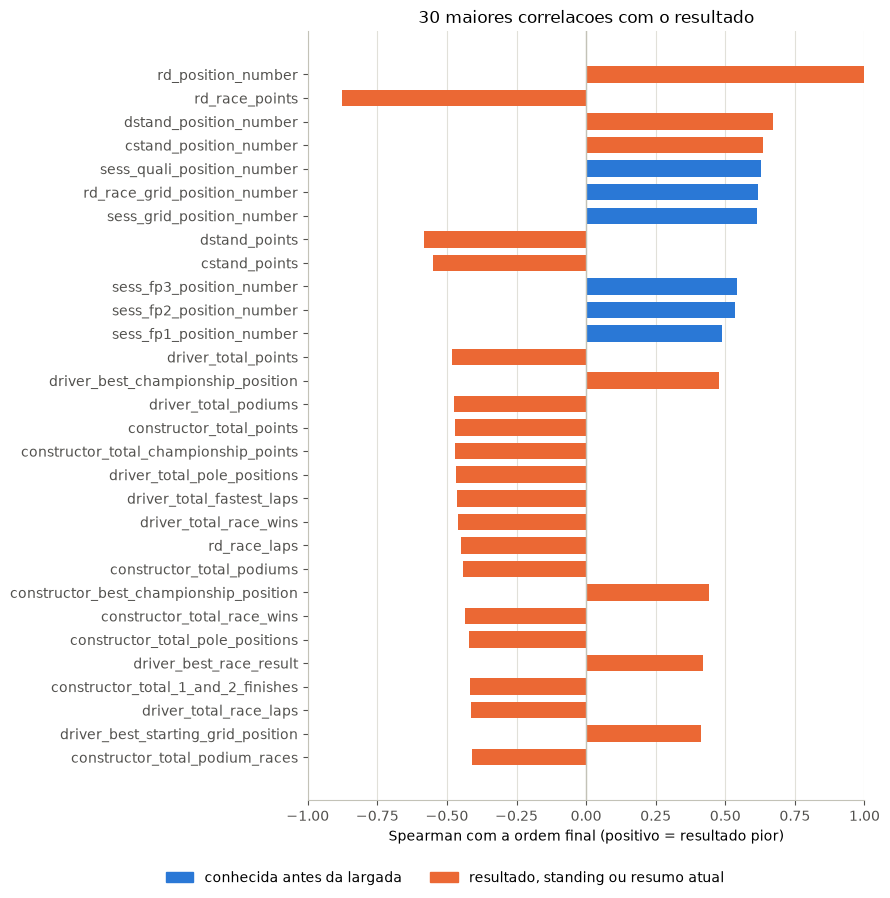

Maiores diferencas entre Spearman e Pearson:


,spearman,pearson,diferenca,assimetria
dstand_points,-0.582,-0.460,-0.122,2.514
cstand_points,-0.550,-0.437,-0.113,2.360
driver_total_race_wins,-0.461,-0.364,-0.097,2.433
driver_total_pole_positions,-0.468,-0.373,-0.095,2.503
rd_race_laps,-0.450,-0.539,0.089,-1.502
rd_race_positions_gained,-0.075,-0.159,0.085,0.175


In [9]:
principais = tabela_alvo.head(30).iloc[::-1]
cores = np.where(principais['momento'].eq('pre-largada'), AZUL, LARANJA)

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(principais.index, principais['spearman'], color=cores, height=0.7)
ax.axvline(0, color='#c3c2b7', linewidth=1)
ax.set(xlim=(-1, 1), xlabel='Spearman com a ordem final (positivo = resultado pior)',
       title='30 maiores correlacoes com o resultado')
ax.grid(axis='y', visible=False)
fig.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color=AZUL, label='conhecida antes da largada'),
    plt.Rectangle((0, 0), 1, 1, color=LARANJA, label='resultado, standing ou resumo atual'),
], loc='lower center', ncol=2, frameon=False)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

print('Maiores diferencas entre Spearman e Pearson:')
display(tabela_alvo.loc[tabela_alvo['diferenca'].abs().sort_values(ascending=False).index].head(6)
        [['spearman', 'pearson', 'diferenca']].join(assimetria).round(3))

Leitura da tabela:

- **As tres correlacoes mais fortes nao sao conhecidas antes da largada.** `rd_position_number` tem Spearman 1,000 porque e a mesma ordem, restrita aos classificados (secao 10). `rd_race_points` (-0,877) usa apenas as 3.800 linhas que pontuaram (secao 3). `dstand_position_number` (0,673) e a posicao no campeonato ja atualizada com a propria corrida (secao 7). Elas descrevem o resultado; nao servem para prever.
- **Entre as variaveis pre-largada, as mais correlacionadas sao classificacao e grid.** `sess_quali_position_number` tem 0,627, `rd_race_grid_position_number` 0,617 e `sess_grid_position_number` 0,615. Os treinos livres vem depois: FP3 0,541, FP2 0,535 e FP1 0,488. O sinal positivo indica que largar mais atras acompanha chegar mais atras.
- **Os resumos de piloto e de equipe** (`driver_total_*`, `driver_best_*`, `constructor_total_*`, `constructor_best_*`) ficam entre 0,332 e 0,483 em modulo. A secao 7, porem, mostra que sao fotografias tiradas depois de todas as corridas.
- **Pearson fica abaixo do Spearman, em modulo, nas variaveis mais assimetricas.** As quatro maiores diferencas (0,095 a 0,122) aparecem em pontos do campeonato e em totais de vitorias e poles, todos com assimetria acima de 2,3. Nas duas seguintes, `rd_race_laps` e `rd_race_positions_gained`, ocorre o contrario: Pearson e maior em modulo.
- **As variaveis da corrida** (ano, rodada, distancia, circuito) ficam perto de zero; a secao 6 explica por que isso acontece por construcao.

## 5. Significancia: permutacao dentro da corrida

O teste classico para uma correlacao supoe observacoes independentes, e a secao 1 mostrou que as linhas de uma corrida nao sao. Por isso, embaralhamos o alvo **dentro de cada corrida**: cada permutacao continua sendo 1..N em cada GP, mas perde qualquer relacao com as variaveis. Repetimos o procedimento 200 vezes e medimos a variacao do Spearman sem relacao real (distribuicao nula).

`z` e o Spearman observado menos a media nula, dividido pelo desvio-padrao nulo. Como sao 103 testes, o limite de `|z|` usa a correcao de Bonferroni: 5% divididos por 103, bilateral, com aproximacao normal.

In [10]:
N_PERMUTACOES = 200
rng = np.random.default_rng(2026)

postos = {coluna: df.loc[df[coluna].notna(), coluna].rank() for coluna in variaveis}

def spearman_com(alvo):
    # Spearman = Pearson dos postos, usando so as linhas em que cada variavel existe.
    return pd.Series({
        coluna: np.corrcoef(posto, alvo.loc[posto.index].rank())[0, 1]
        for coluna, posto in postos.items()
    })

observado = spearman_com(df[ALVO])
assert np.allclose(observado, tabela_alvo.loc[observado.index, 'spearman'])

distribuicao_nula = []
for _ in range(N_PERMUTACOES):
    # O posto de numeros aleatorios dentro da corrida e uma permutacao aleatoria de 1..N.
    alvo_permutado = (
        pd.Series(rng.random(len(df)), index=df.index)
        .groupby(df['race_id']).rank(method='first')
    )
    distribuicao_nula.append(spearman_com(alvo_permutado))
distribuicao_nula = pd.DataFrame(distribuicao_nula)

LIMITE_Z = NormalDist().inv_cdf(1 - 0.05 / (2 * len(variaveis)))
significancia = pd.DataFrame({
    'spearman': observado,
    'media_nula': distribuicao_nula.mean(),
    'dp_nulo': distribuicao_nula.std(),
})
constante_na_corrida = significancia['dp_nulo'].lt(1e-9)
significancia['z'] = ((significancia['spearman'] - significancia['media_nula'])
                      / significancia['dp_nulo'].where(~constante_na_corrida))
significancia['conclusao'] = np.select(
    [constante_na_corrida, significancia['z'].abs().ge(LIMITE_Z)],
    ['igual em toda permutacao', 'distinta do acaso'],
    default='compativel com o acaso',
)
tabela_alvo = tabela_alvo.join(significancia[['dp_nulo', 'z', 'conclusao']])

dp_nulo_max = significancia.loc[~constante_na_corrida, 'dp_nulo'].max()
print(f'Limite de |z| (Bonferroni, {len(variaveis)} testes): {LIMITE_Z:.2f}')
print(f'Menor e maior dp nulo (fora as constantes na corrida): '
      f'{significancia.loc[~constante_na_corrida, "dp_nulo"].min():.4f} a {dp_nulo_max:.4f}')
print(f'|Spearman| que supera o limite mesmo com o maior dp nulo: {LIMITE_Z * dp_nulo_max:.3f}')
display(tabela_alvo['conclusao'].value_counts().to_frame('variaveis'))
colunas_resumo = ['spearman', 'n', 'dp_nulo', 'z', 'momento']
print('Variaveis que variam dentro da corrida e nao se distinguem do acaso:')
display(tabela_alvo.loc[tabela_alvo['conclusao'].eq('compativel com o acaso'), colunas_resumo].round(3))
print('Menores |Spearman| entre as variaveis distintas do acaso:')
distintas = tabela_alvo.loc[tabela_alvo['conclusao'].eq('distinta do acaso')]
display(distintas.loc[distintas['spearman'].abs().sort_values().index, colunas_resumo].head(5).round(3))

Limite de |z| (Bonferroni, 103 testes): 3.49
Menor e maior dp nulo (fora as constantes na corrida): 0.0007 a 0.0180
|Spearman| que supera o limite mesmo com o maior dp nulo: 0.063


,variaveis
conclusao,
distinta do acaso,82
igual em toda permutacao,14
compativel com o acaso,7


Variaveis que variam dentro da corrida e nao se distinguem do acaso:


,spearman,n,dp_nulo,z,momento
sess_quali_q3_millis,0.043,3438,0.013,2.222,pre-largada
engine_capacities,0.039,8462,0.001,2.147,Agregação por temporada sem vigência por etapa...
sess_quali_q2_millis,0.038,5439,0.007,2.614,pre-largada
sess_fp1_laps,-0.026,7967,0.007,-2.420,pre-largada
engmfr_total_race_entries,-0.021,8462,0.010,-2.641,Resumo atual de carreira/fabricante; pode incl...
engmfr_total_race_starts,-0.021,8462,0.010,-2.641,Resumo atual de carreira/fabricante; pode incl...
engmfr_best_starting_grid_position,-0.001,8462,0.010,0.590,Resumo atual de carreira/fabricante; pode incl...


Menores |Spearman| entre as variaveis distintas do acaso:


,spearman,n,dp_nulo,z,momento
tyremfr_total_podiums,0.008,8462,0.001,5.997,Resumo atual de carreira/fabricante; pode incl...
tyremfr_total_pole_positions,0.008,8462,0.001,5.997,Resumo atual de carreira/fabricante; pode incl...
tyremfr_total_race_wins,0.008,8462,0.001,5.997,Resumo atual de carreira/fabricante; pode incl...
tyremfr_total_fastest_laps,0.008,8462,0.001,5.997,Resumo atual de carreira/fabricante; pode incl...
tyremfr_total_race_starts,0.008,8462,0.001,5.997,Resumo atual de carreira/fabricante; pode incl...


O maior desvio-padrao nulo e 0,018. Portanto, qualquer |Spearman| acima de 0,063 supera o limite em qualquer variavel, e varias correlacoes bem menores tambem o superam. Com mais de 8 mil linhas, a significancia estatistica quase nao separa as variaveis; o que as separa na secao 4 e a magnitude e o momento em que cada uma e conhecida.

Os tres grupos:

- **Distinta do acaso (82):** inclui todos os resultados, standings e resumos de piloto e equipe comentados na secao 4, alem das posicoes de grid, classificacao e treinos. Significancia nao implica relevancia: os totais do fornecedor de pneus ficam neste grupo com Spearman de apenas 0,008.
- **Compativel com o acaso (7):** mudam dentro da corrida, mas nao passam do limite. Sao os tempos brutos de Q2 e Q3, as voltas do FP1, a cilindrada e tres resumos do fabricante do motor.
- **Igual em toda permutacao (14):** embaralhar o alvo dentro da corrida nao muda o coeficiente (desvio-padrao nulo zero). A secao 6 confirma que sao exatamente as variaveis constantes dentro de cada corrida.

## 6. Variaveis constantes dentro da corrida

Pela secao 1, cada corrida tem as posicoes 1..N. Se uma variavel tem o mesmo valor para todos os pilotos da corrida, a correlacao so pode vir de N. Para verificar isso, normalizamos o alvo para `(posicao - 1) / (N - 1)`, que vai de 0 a 1 em qualquer corrida e remove o efeito de N.

In [11]:
variaveis_da_corrida = [
    coluna for coluna in variaveis
    if df.groupby('race_id')[coluna].nunique(dropna=False).max() == 1
]
alvo_normalizado = (df[ALVO] - 1) / (tamanho_grid - 1)
efeito_da_corrida = pd.DataFrame({
    'spearman_alvo': tabela_alvo.loc[variaveis_da_corrida, 'spearman'],
    'spearman_com_N': [
        df[[coluna]].join(tamanho_grid).corr(method='spearman').iloc[0, 1]
        for coluna in variaveis_da_corrida
    ],
    'pearson_alvo_normalizado': df[variaveis_da_corrida].corrwith(alvo_normalizado),
})
print(f'Variaveis constantes dentro da corrida: {len(variaveis_da_corrida)}')
print(f'Spearman entre N e o alvo: {df[[ALVO]].join(tamanho_grid).corr(method="spearman").iloc[0, 1]:.3f}')
display(efeito_da_corrida.style.format({
    'spearman_alvo': '{:.3f}', 'spearman_com_N': '{:.3f}', 'pearson_alvo_normalizado': '{:.1e}',
}))
assert set(variaveis_da_corrida) == set(tabela_alvo.index[tabela_alvo['conclusao'].eq('igual em toda permutacao')])
assert efeito_da_corrida['pearson_alvo_normalizado'].abs().max() < 1e-10

Variaveis constantes dentro da corrida: 14
Spearman entre N e o alvo: 0.112


,spearman_alvo,spearman_com_N,pearson_alvo_normalizado
race_year,-0.032,-0.293,-7.2e-18
race_round,-0.007,-0.068,9.4e-18
race_course_length,0.007,0.053,-1.5e-18
race_turns,0.004,0.020,-6.3e-18
race_laps,-0.007,-0.049,0.0e+00
race_distance,0.006,0.050,-3.1e-18
race_drivers_championship_decider,-0.001,-0.011,9.7e-18
race_constructors_championship_decider,-0.001,-0.007,6.6e-18
circuit_length,0.004,0.026,-9.0e-18
circuit_turns,-0.001,-0.021,2.1e-17


As 14 variaveis constantes dentro da corrida sao exatamente as que nao mudaram em nenhuma permutacao da secao 5. Com o alvo normalizado, a correlacao de Pearson com todas elas fica na ordem de 1e-17, ou seja, zero numerico. O pequeno Spearman com o alvo bruto (no maximo 0,032 em modulo, em `race_year`) vem apenas do tamanho do grid. N se correlaciona com o alvo (0,112), porque um grid maior tem posicao media maior. `race_year` e a variavel da corrida mais associada a N (-0,293), com grids de 22 a 24 carros em 2010-2012 e de 20 na maior parte das temporadas recentes (secao 1).

Conclusao: **ano, rodada, distancia, comprimento e historico do circuito nao ordenam os pilotos dentro de uma corrida**. A correlacao marginal nao avalia interacoes. Por exemplo, o circuito ainda pode mudar o peso do grid; essa hipotese nao e testada aqui.

## 7. Resumos de carreira e classificacao do campeonato

A funcao `leakage_risk` marca `driver_*`, `constructor_*`, `engmfr_*` e `tyremfr_*` (total/best) como resumos atuais, e `dstand_*`/`cstand_*` como standings posteriores a corrida. As duas regras podem ser conferidas nos dados.

In [12]:
familias = {
    'driver_total_ / driver_best_': ('driver_id', r'^driver_(total|best)_'),
    'constructor_total_ / constructor_best_': ('constructor_id', r'^constructor_(total|best)_'),
    'engmfr_total_ / engmfr_best_': ('engmfr_id', r'^engmfr_(total|best)_'),
    'tyremfr_total_': ('tyremfr_id', r'^tyremfr_total_'),
}
linhas = []
for familia, (chave, padrao) in familias.items():
    colunas = df.filter(regex=padrao).columns
    linhas.append({
        'familia': familia,
        'colunas': len(colunas),
        'entidades': df[chave].nunique(),
        'temporadas_por_entidade_mediana': df.groupby(chave)['race_year'].nunique().median(),
        'max_valores_distintos_por_entidade': int(df.groupby(chave)[colunas].nunique().max().max()),
    })
fotografia = pd.DataFrame(linhas)
display(fotografia)
assert fotografia['max_valores_distintos_por_entidade'].eq(1).all()

print('Exemplo: Fernando Alonso, uma linha por temporada')
display(df.loc[df['driver_id'].eq('fernando-alonso'),
               ['race_year', 'driver_total_race_wins', 'driver_total_race_entries']]
        .drop_duplicates('race_year').head(4))

primeira_etapa = df.loc[df['race_round'].eq(1) & df['dstand_points'].notna()]
pontos_da_corrida = primeira_etapa['rd_race_points'].fillna(0)
iguais = primeira_etapa['dstand_points'].eq(pontos_da_corrida)
print(f'Rodada 1: dstand_points igual aos pontos da propria corrida em '
      f'{int(iguais.sum())} de {len(primeira_etapa)} linhas')
assert iguais.all()

,familia,colunas,entidades,temporadas_por_entidade_mediana,max_valores_distintos_por_entidade
0,driver_total_ / driver_best_,14,117,3.0,1
1,constructor_total_ / constructor_best_,15,38,3.0,1
2,engmfr_total_ / engmfr_best_,14,16,3.0,1
3,tyremfr_total_,8,3,8.0,1


Exemplo: Fernando Alonso, uma linha por temporada


,race_year,driver_total_race_wins,driver_total_race_entries
6,2003,32,441
282,2004,32,441
620,2005,32,441
956,2006,32,441


Rodada 1: dstand_points igual aos pontos da propria corrida em 283 de 283 linhas


- **Resumos de carreira:** cada piloto, equipe, motor ou fornecedor de pneus tem um unico valor em todas as suas linhas, embora cada entidade apareca, em mediana, em 3 ou mais temporadas. O valor e o total da base inteira, repetido em todas as temporadas. As linhas de Alonso de 2003 a 2006 mostram as mesmas 32 vitorias e 441 inscricoes, entao os valores de 2003 ja contam corridas de anos seguintes. A correlacao de 0,332 a 0,483 dos resumos de piloto e equipe com o resultado inclui desempenho futuro e nao mede o que se sabia antes da corrida.
- **Standings:** na primeira rodada de cada temporada, os pontos do piloto no campeonato sao iguais aos pontos feitos naquela corrida em 283 de 283 linhas (pontos nulos contados como zero). O standing ja inclui a propria corrida. `dstand_position_number` (0,673) e `cstand_position_number` (0,635) superam o grid, mas ja contem o resultado que se quer prever.

Historicos calculados so com corridas anteriores, como os de `feature_engineering.py`, sao a forma correta de usar essa informacao.

## 8. Grid, classificacao e treinos livres

Esta secao detalha a correlacao do grid com o resultado. Usamos `sess_grid_position_number`, que tem mais linhas preenchidas; a comparacao com `rd_race_grid_position_number` confirma que as duas registram o mesmo grid.

In [13]:
GRID = 'sess_grid_position_number'
QUALI = 'sess_quali_position_number'

ambos = df[GRID].notna() & df['rd_race_grid_position_number'].notna()
print(f'{GRID}: n = {df[GRID].notna().sum():,} | rd_race_grid_position_number: n = {df["rd_race_grid_position_number"].notna().sum():,}')
print(f'Valores iguais quando as duas existem: {df.loc[ambos, GRID].eq(df.loc[ambos, "rd_race_grid_position_number"]).mean():.2%} de {ambos.sum():,}')

ambos = df[GRID].notna() & df[QUALI].notna()
print(f'\nGrid igual a posicao de classificacao: {df.loc[ambos, GRID].eq(df.loc[ambos, QUALI]).mean():.1%} das linhas')
print(f'Spearman grid x classificacao: {matriz_spearman.loc[GRID, QUALI]:.3f}')
distancia_quali = (df.loc[ambos, GRID] - df.loc[ambos, QUALI]).abs()
distancia_quali = distancia_quali[distancia_quali.gt(0)]
print(f'Quando diferem: mediana {distancia_quali.median():.0f} posicao | ate 2 posicoes em '
      f'{distancia_quali.le(2).mean():.1%} | p90 {distancia_quali.quantile(0.9):.0f} | max {distancia_quali.max():.0f}')

classificado = df['rd_position_number'].notna()
print('\nSpearman grid x ordem final:')
for rotulo, filtro in [('todos os pilotos', df.index == df.index), ('apenas classificados', classificado)]:
    dados = df.loc[filtro, [GRID, ALVO]].dropna()
    print(f'  {rotulo}: {dados.corr(method="spearman").iloc[0, 1]:.3f} (n = {len(dados):,})')

faixa_grid = pd.cut(df[GRID], [0, 5, 10, 15, 20, 26], labels=['1-5', '6-10', '11-15', '16-20', '21+'])
print('\nParcela de nao classificados por faixa de largada:')
display((~classificado).groupby(faixa_grid, observed=True).agg(['mean', 'size'])
        .rename(columns={'mean': 'nao_classificados', 'size': 'linhas'})
        .style.format({'nao_classificados': '{:.1%}'}))

sess_grid_position_number: n = 8,331 | rd_race_grid_position_number: n = 8,282
Valores iguais quando as duas existem: 99.93% de 8,281

Grid igual a posicao de classificacao: 74.3% das linhas
Spearman grid x classificacao: 0.973
Quando diferem: mediana 1 posicao | ate 2 posicoes em 78.1% | p90 4 | max 18

Spearman grid x ordem final:
  todos os pilotos: 0.615 (n = 8,331)
  apenas classificados: 0.755 (n = 6,807)

Parcela de nao classificados por faixa de largada:


,nao_classificados,linhas
sess_grid_position_number,,
1-5,11.0%,2015
6-10,16.8%,2013
11-15,20.4%,2015
16-20,23.9%,1915
21+,25.2%,373


- Os dois registros de grid concordam em 99,9% das linhas, entao a escolha entre eles nao muda o resultado.
- O grid e a classificacao coincidem em 74,3% das linhas, e o Spearman entre eles e 0,973. Quando diferem, a mediana da diferenca e de 1 posicao, 78,1% dos casos ficam em ate 2 posicoes e 90% em ate 4. O maior caso chega a 18.
- **Os nao classificados enfraquecem a correlacao.** Entre os classificados, o Spearman grid x resultado sobe de 0,615 para 0,755. Pela definicao do alvo, pilotos nao classificados vao para o fim da ordem independentemente de onde largaram. A parcela deles tambem cresce com a posicao de largada, de 11,0% (1-5) para 25,2% (21+).

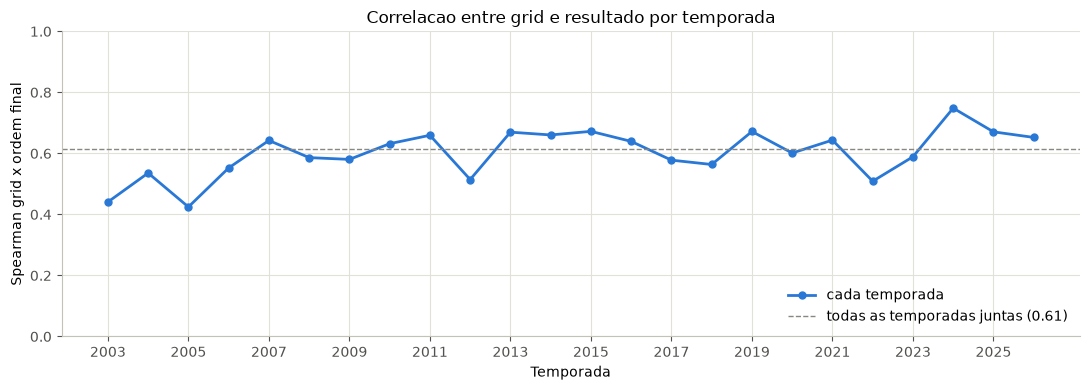

Por temporada: min 0.425 (2005) | max 0.748 (2024)
Por corrida (um Spearman por GP):


,spearman_grid
count,403.000
mean,0.601
std,0.210
min,-0.135
25%,0.472
50%,0.642
75%,0.757
max,0.964


In [14]:
por_temporada = df.groupby('race_year')[[GRID, ALVO]].apply(lambda d: d.corr(method='spearman').iloc[0, 1])
por_gp = df.groupby('race_id')[[GRID, ALVO]].apply(lambda d: d.corr(method='spearman').iloc[0, 1])
geral = tabela_alvo.loc[GRID, 'spearman']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(por_temporada.index, por_temporada.values, color=AZUL, linewidth=2, marker='o', markersize=5,
        label='cada temporada')
ax.axhline(geral, color=CINZA, linestyle='--', linewidth=1, label=f'todas as temporadas juntas ({geral:.2f})')
ax.legend(loc='lower right', frameon=False)
ax.set(ylim=(0, 1), xlabel='Temporada', ylabel='Spearman grid x ordem final',
       title='Correlacao entre grid e resultado por temporada')
ax.set_xticks(por_temporada.index[::2])
plt.tight_layout()
plt.show()

print(f'Por temporada: min {por_temporada.min():.3f} ({por_temporada.idxmin()}) | '
      f'max {por_temporada.max():.3f} ({por_temporada.idxmax()})')
print('Por corrida (um Spearman por GP):')
display(por_gp.describe().round(3).to_frame('spearman_grid'))

A relacao grid x resultado e positiva em todas as temporadas. Ela varia de 0,425 (2005) a 0,748 (2024) e nao tem uma tendencia unica: 2022, por exemplo, volta a 0,509. Corrida a corrida, a dispersao e grande. A mediana e 0,64, mas ha GPs com correlacao negativa. Um coeficiente medio de 0,6 nao garante que o grid ordene bem uma corrida especifica.

Como o objetivo final do projeto inclui prever o vencedor, a tabela abaixo mostra a mesma relacao para o alvo binario:

In [15]:
vitorias = pd.DataFrame({'venceu': df[ALVO].eq(1), 'largada': df[GRID].clip(upper=11)})
taxa = vitorias.groupby('largada')['venceu'].agg(['sum', 'size', 'mean'])
taxa.index = [f'{int(p)}' if p < 11 else '11+' for p in taxa.index]
taxa.columns = ['vitorias', 'largadas', 'taxa_de_vitoria']
display(taxa.style.format({'taxa_de_vitoria': '{:.1%}'}))
print(f'Vitorias de pilotos sem grid registrado: {int(df.loc[df[GRID].isna(), ALVO].eq(1).sum())}')

,vitorias,largadas,taxa_de_vitoria
1,221,403,54.8%
2,94,403,23.3%
3,35,403,8.7%
4,17,403,4.2%
5,7,403,1.7%
6,8,403,2.0%
7,6,403,1.5%
8,2,402,0.5%
9,1,403,0.2%
10,4,402,1.0%


Vitorias de pilotos sem grid registrado: 0


A taxa de vitoria cai rapidamente com a posicao de largada. A pole venceu 54,8% das corridas e a segunda posicao 23,3%. Da quinta posicao em diante, nenhuma passa de 2%. As tres primeiras somam 350 das 403 vitorias (86,8%). Um coeficiente unico resume a relacao monotonica, mas nao mostra essa concentracao no topo do grid.

## 9. Tempos de volta e o efeito do circuito

Os tempos em milissegundos quase nao se correlacionam com o resultado (Spearman de 0,04 a 0,12 na secao 4). A hipotese e que o tempo bruto mede principalmente o tamanho da pista, e nao a diferenca entre pilotos. Para testar, comparamos cada tempo com o comprimento da volta e criamos o tempo relativo: `tempo / melhor tempo da sessao na mesma corrida - 1`.

In [16]:
colunas_tempo = [
    'sess_fp1_time_millis', 'sess_fp2_time_millis', 'sess_fp3_time_millis',
    'sess_quali_q1_millis', 'sess_grid_time_millis', 'sess_fastest_lap_time_millis',
]
tempo_relativo = pd.DataFrame({
    coluna.replace('_millis', '_rel'): df[coluna] / df.groupby('race_id')[coluna].transform('min') - 1
    for coluna in colunas_tempo
})

linhas = []
for coluna, relativo in zip(colunas_tempo, tempo_relativo.columns):
    dados = pd.concat([df[[coluna, 'race_course_length', ALVO]], tempo_relativo[relativo]], axis=1)
    c = dados.corr(method='spearman')
    linhas.append({
        'tempo': coluna, 'n': int(df[coluna].notna().sum()), 'momento': leakage_risk(coluna) or 'pre-largada',
        'bruto_x_comprimento': c.loc[coluna, 'race_course_length'],
        'bruto_x_alvo': c.loc[coluna, ALVO],
        'relativo_x_comprimento': c.loc[relativo, 'race_course_length'],
        'relativo_x_alvo': c.loc[relativo, ALVO],
    })
display(pd.DataFrame(linhas).set_index('tempo').round(3))

treinos = colunas_tempo[:3] + ['sess_grid_time_millis']
entre_brutos = df[treinos].corr(method='spearman').where(np.triu(np.ones((4, 4), dtype=bool), k=1)).stack()
entre_relativos = tempo_relativo[[c.replace('_millis', '_rel') for c in treinos]].corr(method='spearman')
entre_relativos = entre_relativos.where(np.triu(np.ones((4, 4), dtype=bool), k=1)).stack()
print(f'Spearman entre tempos de FP1/FP2/FP3/grid - brutos: {entre_brutos.min():.2f} a {entre_brutos.max():.2f} | '
      f'relativos: {entre_relativos.min():.2f} a {entre_relativos.max():.2f}')

,n,momento,bruto_x_comprimento,bruto_x_alvo,relativo_x_comprimento,relativo_x_alvo
tempo,,,,,,
sess_fp1_time_millis,7623,pre-largada,0.782,0.072,-0.028,0.479
sess_fp2_time_millis,8181,pre-largada,0.792,0.074,-0.043,0.507
sess_fp3_time_millis,8025,pre-largada,0.760,0.074,-0.042,0.504
sess_quali_q1_millis,7407,pre-largada,0.767,0.062,-0.016,0.506
sess_grid_time_millis,8121,pre-largada,0.758,0.076,-0.010,0.511
sess_fastest_lap_time_millis,8119,Volta mais rápida durante a corrida,0.777,0.121,-0.082,0.655


Spearman entre tempos de FP1/FP2/FP3/grid - brutos: 0.92 a 0.96 | relativos: 0.60 a 0.70


A hipotese se confirma:

- O tempo bruto tem Spearman de 0,76 a 0,79 com o comprimento da volta e apenas 0,06 a 0,12 com o resultado. Ele mede a pista.
- O tempo relativo quase nao tem relacao com o comprimento (|Spearman| <= 0,08) e sobe para cerca de 0,48 a 0,51 com o resultado nos treinos, classificacao e grid. Fica no mesmo nivel das posicoes de treino da secao 4.
- A correlacao entre os tempos brutos de sessoes diferentes (0,92 a 0,96) cai para 0,60 a 0,70 quando os tempos sao relativos. A maior parte da redundancia entre tempos vem do circuito que todos compartilham.
- `sess_fastest_lap_time_millis` relativo tem a maior correlacao (0,655), mas `leakage_risk` o marca como volta mais rapida **durante a corrida**. Ele descreve a propria prova.

### Resumo das variaveis pre-largada

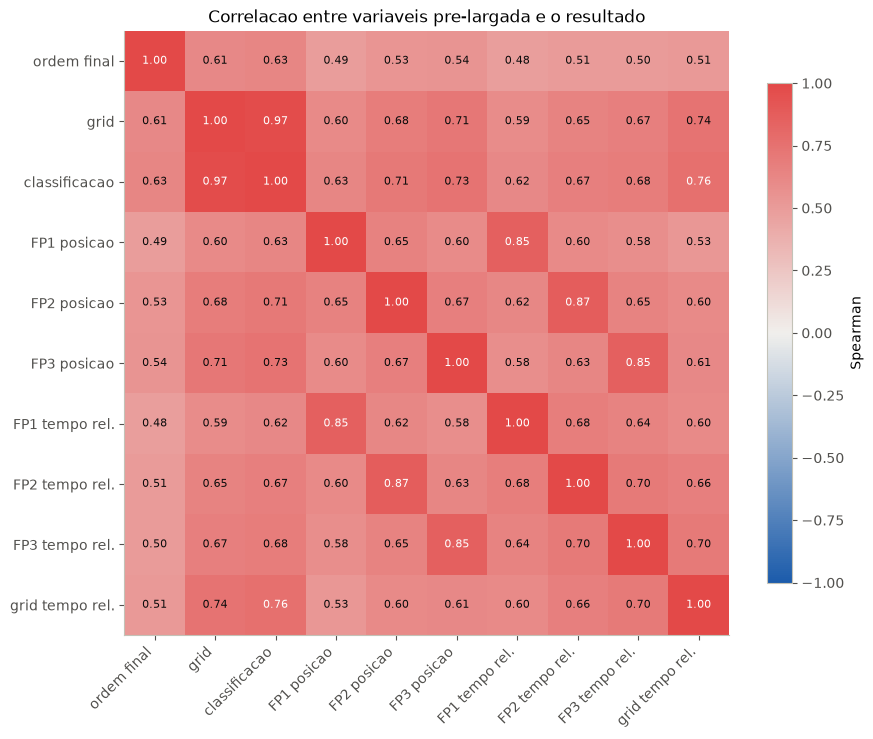

,count,min,max
tipo,,,
com o resultado,9,0.48,0.63
mesma sessao,6,0.74,0.97
sessoes diferentes,30,0.53,0.73


In [17]:
pre_largada = pd.concat([
    df[[ALVO, GRID, QUALI, 'sess_fp1_position_number', 'sess_fp2_position_number', 'sess_fp3_position_number']],
    tempo_relativo[['sess_fp1_time_rel', 'sess_fp2_time_rel', 'sess_fp3_time_rel', 'sess_grid_time_rel']],
], axis=1)
rotulos = ['ordem final', 'grid', 'classificacao', 'FP1 posicao', 'FP2 posicao', 'FP3 posicao',
           'FP1 tempo rel.', 'FP2 tempo rel.', 'FP3 tempo rel.', 'grid tempo rel.']
correlacao_pre = pre_largada.corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7.5))
imagem = ax.imshow(correlacao_pre, cmap=MAPA_DIVERGENTE, vmin=-1, vmax=1)
ax.set_xticks(range(len(rotulos)), rotulos, rotation=45, ha='right')
ax.set_yticks(range(len(rotulos)), rotulos)
ax.grid(False)
for i in range(len(rotulos)):
    for j in range(len(rotulos)):
        valor = correlacao_pre.iloc[i, j]
        ax.text(j, i, f'{valor:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(valor) > 0.75 else '#0b0b0b')
fig.colorbar(imagem, ax=ax, shrink=0.8, label='Spearman')
ax.set_title('Correlacao entre variaveis pre-largada e o resultado')
plt.tight_layout()
plt.show()

# Grid, posicao e tempo de classificacao saem da mesma sessao.
sessao = ['resultado', 'classificacao', 'classificacao', 'FP1', 'FP2', 'FP3', 'FP1', 'FP2', 'FP3', 'classificacao']
linha, coluna = np.triu_indices(len(sessao), k=1)
pares_pre = pd.DataFrame({
    'valor': correlacao_pre.to_numpy()[linha, coluna],
    'tipo': ['com o resultado' if 'resultado' in (sessao[i], sessao[j])
             else 'mesma sessao' if sessao[i] == sessao[j] else 'sessoes diferentes'
             for i, j in zip(linha, coluna)],
})
display(pares_pre.groupby('tipo')['valor'].agg(['count', 'min', 'max']).round(2))

Todos os pares da matriz sao positivos, com minimo de 0,48: um piloto a frente em uma sessao tende a estar a frente nas outras e no resultado. Medidas da mesma sessao ficam entre 0,74 e 0,97. Grid e classificacao sao quase a mesma informacao (0,97), e posicao e tempo relativo do mesmo treino ficam entre 0,85 e 0,87. Entre sessoes diferentes, a faixa vai de 0,53 a 0,73; com o resultado, de 0,48 a 0,63. Um modelo que use todas essas colunas recebera informacao bastante repetida.

## 10. Pares redundantes (|Spearman| >= 0,9)

Correlacoes muito altas entre duas variaveis indicam que elas carregam quase a mesma informacao. A tabela agrupa os pares pela familia do prefixo de cada coluna.

In [18]:
def familia(coluna):
    prefixo = coluna.split('_')[0]
    return prefixo if prefixo in {'driver', 'constructor', 'engmfr', 'tyremfr', 'sess', 'race', 'circuit',
                                  'layout', 'rd', 'dstand', 'cstand', 'gp', 'engine', 'ed'} else coluna

redundantes = pares.loc[pares['spearman'].abs().ge(0.9)].copy()
redundantes['familias'] = [
    ' x '.join(sorted({familia(a), familia(b)})) for a, b in zip(redundantes['variavel_a'], redundantes['variavel_b'])
]
print(f'Pares com |Spearman| >= 0,9: {len(redundantes)}')
display(redundantes['familias'].value_counts().to_frame('pares'))

resumos = {'driver', 'constructor', 'engmfr', 'tyremfr'}
fora_dos_resumos = redundantes.loc[~redundantes['familias'].isin(resumos)]
fora_dos_resumos = fora_dos_resumos.loc[fora_dos_resumos['spearman'].abs().sort_values(ascending=False).index]
print('Pares fora das familias de resumo de carreira/fabricante:')
display(fora_dos_resumos.round(3).reset_index(drop=True))

Pares com |Spearman| >= 0,9: 138


,pares
familias,
constructor,30
sess,30
tyremfr,28
engmfr,21
driver,16
circuit x race,3
rd x sess,2
layout x race,2
cstand x dstand,2


Pares fora das familias de resumo de carreira/fabricante:


,variavel_a,variavel_b,spearman,n,familias
0,rd_position_display_order,rd_position_number,1.000,6898,rd
1,sess_grid_time_millis,sess_quali_q3_millis,1.000,3433,sess
2,sess_grid_time_millis,sess_quali_time_millis,1.000,906,sess
3,rd_race_grid_position_number,sess_grid_position_number,1.000,8281,rd x sess
4,race_course_length,layout_length,1.000,8462,layout x race
5,race_laps,layout_length,-0.997,8462,layout x race
6,race_course_length,race_laps,-0.997,8462,race
7,sess_grid_time_millis,sess_quali_q2_millis,0.994,5331,sess
8,sess_quali_q2_millis,sess_quali_q3_millis,0.991,3438,sess
9,sess_quali_q1_millis,sess_quali_q2_millis,0.982,5437,sess


As quatro familias de resumos (`constructor`, `tyremfr`, `engmfr` e `driver`) somam 95 dos 138 pares. Na secao 7, cada uma dessas colunas tem um valor fixo por entidade. Assim, dentro de cada familia, as colunas descrevem as mesmas poucas entidades de varias formas. O caso extremo e `tyremfr_*`: com apenas 3 fornecedores, todos os 28 pares possiveis entre as 8 colunas passam de 0,9. As demais explicacoes se conferem abaixo:

In [19]:
def iguais(a, b):
    ambos = df[a].notna() & df[b].notna()
    return f'{df.loc[ambos, a].eq(df.loc[ambos, b]).mean():.2%} de {ambos.sum():,} linhas'

print('Colunas que registram a mesma medida:')
print(f'  rd_position_display_order = rd_position_number: {iguais(ALVO, "rd_position_number")}')
print(f'  sess_grid_position_number = rd_race_grid_position_number: {iguais(GRID, "rd_race_grid_position_number")}')
print(f'  race_course_length = layout_length: {iguais("race_course_length", "layout_length")}; '
      f'maior diferenca {(df["race_course_length"] - df["layout_length"]).abs().max():.3f} km')
melhor_segmento = df[['sess_quali_q3_millis', 'sess_quali_q2_millis', 'sess_quali_q1_millis', 'sess_quali_time_millis']].bfill(axis=1).iloc[:, 0]
com_tempo = df['sess_grid_time_millis'].notna()
print(f'  sess_grid_time_millis = ultimo segmento de classificacao: '
      f'{df.loc[com_tempo, "sess_grid_time_millis"].eq(melhor_segmento[com_tempo]).mean():.2%} de {com_tempo.sum():,} linhas')

distancia = df.drop_duplicates('race_id')['race_distance']
print(f'\nDistancia da corrida (uma linha por GP): mediana {distancia.median():.1f} km | '
      f'p5 {distancia.quantile(0.05):.1f} | p95 {distancia.quantile(0.95):.1f}')
erro_distancia = (df['race_laps'] * df['race_course_length'] - df['race_distance']).abs().max()
print(f'Maior |voltas x comprimento - distancia|: {erro_distancia:.3f} km')

por_circuito = df.groupby('circuit_id')[['circuit_length', 'circuit_turns', 'race_course_length', 'race_turns']].nunique()
print('\nValores distintos por circuito:')
display(por_circuito.agg(['max', lambda s: int(s.gt(1).sum())]).set_axis(['maximo', 'circuitos com mais de um']))

print('\nCilindrada por temporada:')
display(df.groupby('race_year')['engine_capacities'].agg(lambda s: ', '.join(map(str, sorted(s.unique())))).to_frame().T)
print(f'Fornecedores de pneus distintos: {df["tyremfr_id"].nunique()}')

ambos = df['cstand_points'].notna() & df['dstand_points'].notna()
print(f'Pontos da equipe >= pontos do piloto: {(df.loc[ambos, "cstand_points"] >= df.loc[ambos, "dstand_points"]).mean():.1%} das linhas')

Colunas que registram a mesma medida:
  rd_position_display_order = rd_position_number: 100.00% de 6,898 linhas
  sess_grid_position_number = rd_race_grid_position_number: 99.93% de 8,281 linhas
  race_course_length = layout_length: 92.86% de 8,462 linhas; maior diferenca 0.039 km
  sess_grid_time_millis = ultimo segmento de classificacao: 99.89% de 8,121 linhas

Distancia da corrida (uma linha por GP): mediana 306.7 km | p5 260.5 | p95 309.7
Maior |voltas x comprimento - distancia|: 0.366 km

Valores distintos por circuito:


,circuit_length,circuit_turns,race_course_length,race_turns
maximo,1,1,5,3
circuitos com mais de um,0,0,10,7



Cilindrada por temporada:


race_year,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
engine_capacities,3.0,3.0,3.0,"2.4, 3.0",2.4,2.4,2.4,2.4,2.4,2.4,2.4,1.6,1.6,1.6,1.6,1.6,1.6,1.6,1.6,1.6,1.6,1.6,1.6,1.6


Fornecedores de pneus distintos: 3
Pontos da equipe >= pontos do piloto: 99.2% das linhas


- **Mesma medida em duas colunas:** a ordem completa e a posicao classificada sao iguais em 100% das linhas classificadas. Os dois registros de grid concordam em 99,93% das linhas. `race_course_length` e `layout_length` sao iguais em 92,86% das linhas e, nas demais, diferem no maximo 39 m. `sess_grid_time_millis` e o tempo do ultimo segmento de classificacao em 99,89% das linhas, por isso correlaciona 1,0 com Q3 e com o tempo unico de 2003-2005.
- **Voltas x comprimento (-0,997):** voltas vezes comprimento reproduz a distancia com erro maximo de 0,366 km, e a distancia e quase fixa (90% dos GPs entre 260,5 e 309,7 km). Com a distancia quase constante, mais comprimento significa menos voltas.
- **Corrida x circuito (0,92-0,97):** `circuit_length` e `circuit_turns` tem um unico valor por circuito, enquanto `race_course_length` e `race_turns` mudam em alguns circuitos (tabela acima). As colunas `circuit_*` descrevem o circuito com um valor fixo; as `race_*`, a configuracao usada em cada corrida. Elas so divergem nos circuitos que mudaram.
- **Ano x cilindrada (-0,90):** a cilindrada muda em degraus entre temporadas, com 3,0 ate 2005, 2,4 de 2006 a 2013 (2006 ainda tem os dois valores) e 1,6 desde 2014. Ela funciona como marcador de epoca.
- **Standings do piloto x da equipe (0,91-0,94):** os pontos da equipe sao maiores ou iguais aos do piloto em 99,2% das linhas, o que e coerente com a pontuacao da equipe incluir a de seus pilotos.
- **Tempos de sessoes diferentes:** a secao 9 mostrou que essa redundancia vem do circuito compartilhado.

Cada grupo e candidato a manter uma unica coluna. A escolha deve considerar o momento em que cada variavel e conhecida (secao 2) e a cobertura de nulos (secao 3).

## 11. Variaveis categoricas: razao de correlacao (eta²)

Piloto, equipe e circuito nao tem ordem, entao Spearman nao se aplica. Usamos a razao de correlacao ao quadrado (eta²): a fracao da variancia da ordem final explicada pelas medias de cada categoria. Ela vai de 0 a 1. Mesmo sem relacao real, eta² cresce com o numero de categorias. Por isso, cada valor e comparado com a mesma permutacao dentro da corrida da secao 5.

As colunas de texto espelho da secao 2 ficam de fora. As datas entram como categorias: `race_date` tem um valor por corrida, e `driver_date_of_birth` tem tantos valores quanto pilotos (tabela abaixo).

In [20]:
def eta2(categoria, alvo):
    grupos = alvo.groupby(categoria)
    media = alvo[categoria.notna()].mean()
    entre = (grupos.size() * (grupos.mean() - media) ** 2).sum()
    total = ((alvo[categoria.notna()] - media) ** 2).sum()
    return entre / total

observado_eta = pd.Series({coluna: eta2(df[coluna], df[ALVO]) for coluna in colunas_categoricas})
nulo_eta = []
rng = np.random.default_rng(2026)
for _ in range(N_PERMUTACOES):
    alvo_permutado = (
        pd.Series(rng.random(len(df)), index=df.index)
        .groupby(df['race_id']).rank(method='first')
    )
    nulo_eta.append({coluna: eta2(df[coluna], alvo_permutado) for coluna in colunas_categoricas})
nulo_eta = pd.DataFrame(nulo_eta)

tabela_eta = pd.DataFrame({
    'categorias': df[colunas_categoricas].nunique(),
    'eta2': observado_eta,
    'eta2_nulo_medio': nulo_eta.mean(),
    'eta2_nulo_max': nulo_eta.max(),
})
tabela_eta['acima_do_nulo'] = tabela_eta['eta2'] - tabela_eta['eta2_nulo_medio']
tabela_eta['conclusao'] = np.select(
    [nulo_eta.std().lt(1e-12), tabela_eta['eta2'].gt(tabela_eta['eta2_nulo_max'])],
    ['igual em toda permutacao', 'acima de todas as permutacoes'],
    default='dentro do nulo',
)
display(tabela_eta.sort_values('acima_do_nulo', ascending=False).round(4))

,categorias,eta2,eta2_nulo_medio,eta2_nulo_max,acima_do_nulo,conclusao
chassis_ids,253,0.4246,0.0425,0.0513,0.3821,acima de todas as permutacoes
chassis_names,251,0.4222,0.0423,0.0505,0.3799,acima de todas as permutacoes
ed_entrant_names,96,0.3508,0.0180,0.0241,0.3327,acima de todas as permutacoes
ed_entrant_ids,96,0.3508,0.0180,0.0241,0.3327,acima de todas as permutacoes
constructor_name,38,0.3007,0.0079,0.0129,0.2928,acima de todas as permutacoes
constructor_id,38,0.3007,0.0079,0.0129,0.2928,acima de todas as permutacoes
driver_name,117,0.2703,0.0190,0.0260,0.2513,acima de todas as permutacoes
driver_id,117,0.2703,0.0190,0.0260,0.2513,acima de todas as permutacoes
driver_date_of_birth,117,0.2703,0.0190,0.0260,0.2513,acima de todas as permutacoes
engine_names,118,0.1821,0.0246,0.0294,0.1575,acima de todas as permutacoes


Leitura, a partir de `acima_do_nulo`. Colunas de nome tem eta² igual ou quase igual ao do ID correspondente (a maior diferenca e `chassis_names`, 0,4222 contra 0,4246), entao citamos apenas os IDs:

- **Carro e equipe sao as categorias mais associadas ao resultado.** `chassis_ids` tem o maior eta² (0,42), seguido de `ed_entrant_ids` (0,35) e `constructor_id` (0,30). `driver_id` fica em 0,27, e o modelo de motor (`engine_ids`) em 0,18. Todos estao muito acima do maior valor das 200 permutacoes para a mesma coluna, que chega no maximo a 0,0513.
- **O fabricante do motor tem eta² bem menor** (0,09). Ele agrupa equipes: sao 16 fabricantes para 38 equipes, e um mesmo fabricante chega a 11 equipes (tabela abaixo).
- **O fornecedor de pneus** fica acima de todas as permutacoes, mas com eta² de 0,005. Assim como na secao 5, isso e distinguivel do acaso, mas pequeno.
- **Categorias com o mesmo eta² em todas as permutacoes** (circuito, GP, layout, data, tipo de pista, sentido, formato de classificacao e aspiracao do motor): como na secao 6, o valor delas nao muda quando a ordem dentro da corrida muda, entao elas nao distinguem pilotos dentro da corrida. `engine_configurations` fica dentro da distribuicao nula.

Verificacoes que sustentam essas leituras:

In [21]:
print(f'Temporadas por chassis_ids: max {df.groupby("chassis_ids")["race_year"].nunique().max()}')
equipe_temporada = df['constructor_id'] + '_' + df['race_year'].astype(str)
print(f'Combinacoes equipe x temporada: {equipe_temporada.nunique()} | chassis distintos: {df["chassis_ids"].nunique()}')
print(f'eta2 equipe x temporada: {eta2(equipe_temporada, df[ALVO]):.4f} | eta2 chassis: {tabela_eta.loc["chassis_ids", "eta2"]:.4f}')
print(f'Equipes por piloto: mediana {df.groupby("driver_id")["constructor_id"].nunique().median():.0f} | '
      f'max {df.groupby("driver_id")["constructor_id"].nunique().max()}')
piloto_equipe = df['driver_id'] + '_' + df['constructor_id']
print(f'eta2 piloto: {tabela_eta.loc["driver_id", "eta2"]:.4f} | equipe: {tabela_eta.loc["constructor_id", "eta2"]:.4f} | '
      f'soma: {tabela_eta.loc[["driver_id", "constructor_id"], "eta2"].sum():.4f} | '
      f'piloto x equipe juntos: {eta2(piloto_equipe, df[ALVO]):.4f}')
equipes_por_motor = df.groupby('engmfr_id')['constructor_id'].nunique()
print(f'Fabricantes de motor: {len(equipes_por_motor)} | equipes por fabricante: '
      f'mediana {equipes_por_motor.median():.0f} | max {equipes_por_motor.max()} ({equipes_por_motor.idxmax()})')

Temporadas por chassis_ids: max 1
Combinacoes equipe x temporada: 253 | chassis distintos: 253
eta2 equipe x temporada: 0.4246 | eta2 chassis: 0.4246
Equipes por piloto: mediana 2 | max 9
eta2 piloto: 0.2703 | equipe: 0.3007 | soma: 0.5711 | piloto x equipe juntos: 0.3934
Fabricantes de motor: 16 | equipes por fabricante: mediana 2 | max 11 (ferrari)


- Cada chassi pertence a uma unica temporada. Ha 253 chassis e 253 combinacoes equipe x temporada, e o eta² das duas e identico (0,4246). Na pratica, o chassi e a equipe em um ano especifico. Mesmo descontando o nulo, o ganho de equipe (0,29 acima do nulo) para equipe x temporada (0,38 acima do nulo) mostra que o resultado medio de uma equipe muda entre temporadas. Uma media fixa por equipe perde essa variacao.
- Cada piloto passa, em mediana, por apenas 2 das 38 equipes, entao piloto e equipe se sobrepoem. A combinacao piloto x equipe explica 0,39 da variancia, bem menos que a soma dos eta² isolados (0,27 + 0,30 = 0,57). Parte do que cada um "explica" sozinho e compartilhada, e os eta² marginais **nao separam** o efeito do piloto do efeito do carro.

## 12. Conclusoes

1. **O alvo e uma permutacao de 1..N em cada corrida** (secao 1). As linhas nao sao independentes, e variaveis constantes dentro da corrida so se relacionam com o alvo pelo tamanho do grid. Com o alvo normalizado, essa correlacao e zero numerico (secao 6).
2. **Spearman e a medida adequada** para um alvo ordinal e para as 36 variaveis com assimetria forte. Nas variaveis mais assimetricas, Pearson fica ate 0,12 menor em modulo (secoes 3 e 4).
3. **As maiores correlacoes vem de informacao posterior a largada:** posicao classificada, pontos, standings e resumos de carreira calculados com o historico completo (secoes 4 e 7). Elas nao indicam poder preditivo.
4. **Entre as variaveis pre-largada, classificacao e grid lideram** (Spearman ~0,62), seguidas dos treinos livres (0,49 a 0,54) e dos tempos relativos (~0,48 a 0,51). A correlacao e positiva em todas as temporadas (0,425 a 0,748), mas oscila bastante de corrida para corrida. Os nao classificados reduzem a associacao, que chega a 0,755 entre os classificados (secao 8).
5. **Tempos de volta brutos medem principalmente o circuito** (0,76 a 0,79 com o comprimento da volta; secao 9). O tempo relativo a sessao da mesma corrida carrega muito mais sinal sobre o resultado (0,48 a 0,51, contra 0,06 a 0,08 do tempo bruto nas mesmas sessoes).
6. **Ha redundancia forte** entre grid e classificacao, entre registros duplicados da mesma medida, entre voltas e comprimento e dentro dos resumos de carreira (secao 10).
7. **Entre as categorias, equipe x temporada (chassi) e a mais associada ao resultado**, acima de equipe e piloto isolados. A analise marginal nao separa o efeito do piloto do efeito do carro (secao 11).

Limites: todos os coeficientes sao marginais, pois medem uma variavel por vez, e agregam 2003-2026. Correlacao nao identifica causa; por exemplo, o grid e o resultado podem refletir o mesmo desempenho do carro e do piloto.